In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.drop("Cabin", axis=1, inplace=True)

In [14]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


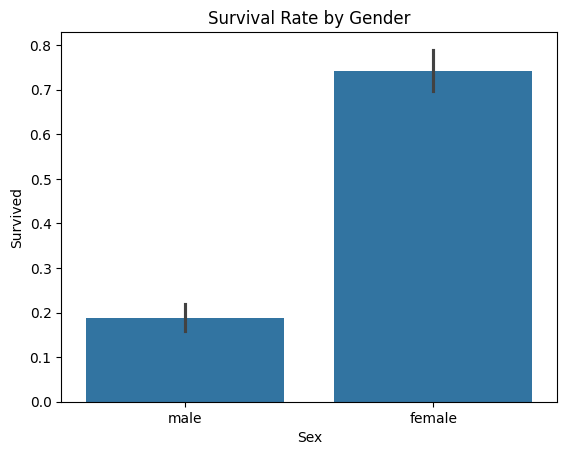

In [15]:
sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")

plt.show()

In [16]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


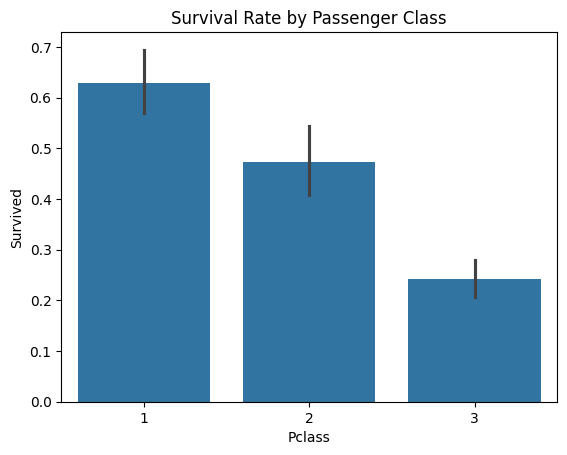

In [17]:
sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")

plt.show()

In [18]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

In [19]:
df.groupby("AgeGroup")["Survived"].mean()

/tmp/ipykernel_595/2602041343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


,Survived
AgeGroup,
Child,0.579710
Teen,0.428571
Young Adult,0.353271
Adult,0.400000
Senior,0.227273


/tmp/ipykernel_595/399819765.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean().plot(kind="bar")


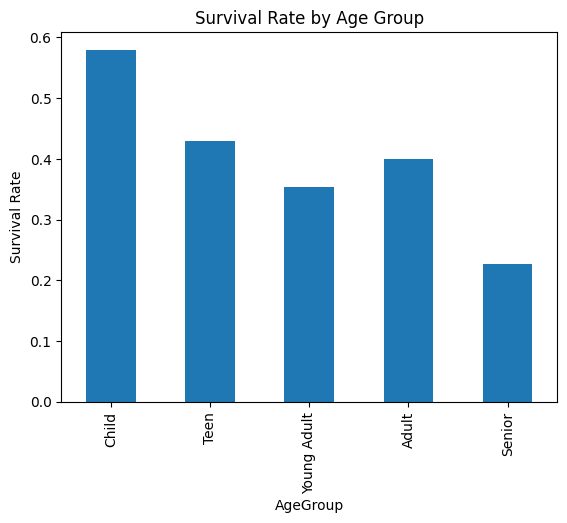

In [20]:
df.groupby("AgeGroup")["Survived"].mean().plot(kind="bar")

plt.title("Survival Rate by Age Group")

plt.ylabel("Survival Rate")

plt.show()

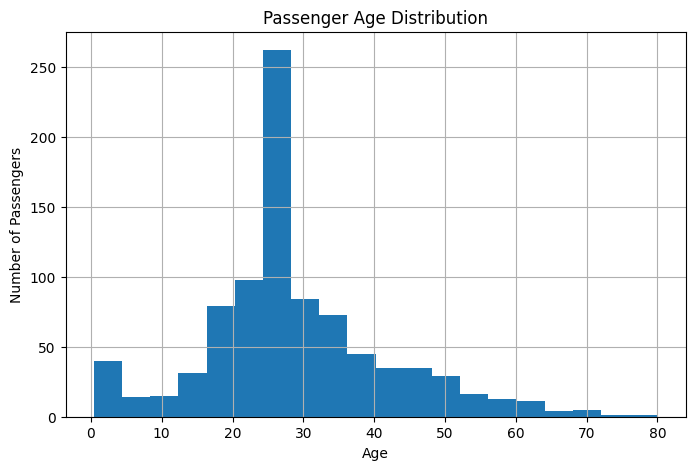

In [21]:
plt.figure(figsize=(8,5))

df["Age"].hist(bins=20)

plt.title("Passenger Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Passengers")

plt.show()

In [22]:
print("""
Conclusion

1. Females survived more than males.
2. First-class passengers had higher survival chances.
3. Children showed better survival rates.
4. Most passengers were between 20 and 40 years old.
""")


Conclusion

1. Females survived more than males.
2. First-class passengers had higher survival chances.
3. Children showed better survival rates.
4. Most passengers were between 20 and 40 years old.

